In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.utils import to_categorical

In [2]:
# --- 0. 헬퍼(Helper) 함수 정의 ---
# (1D_CNN.ipynb 파일에 있던 함수들입니다)

# 텍스트 파일을 읽어와 Numpy 배열로 반환하는 함수
def load_file(filepath):
    # sep='\s+'는 공백(whitespace)을 기준으로 데이터를 나누라는 뜻
    dataframe = pd.read_csv(filepath, header=None, sep=r'\s+')
    return dataframe.values

# 9개 신호 파일(Inertial Signals)을 3D로 스택(stack)하는 함수
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # dstack: (샘플, 128)짜리 9개 배열을 -> (샘플, 128, 9) 형태로 합침
    loaded = np.dstack(loaded)
    return loaded

# --- 1. 데이터셋 경로 및 파일 이름 정의 ---
DATASET_PATH = r'/content/drive/MyDrive/UCI HAR Dataset/'

# Inertial Signals 폴더에 있는 9개 파일 목록
SIGNALS = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

# --- 2. 훈련(Train) 데이터 로딩 ---
# X_train (피처): 9개 신호 파일을 3D로 불러오기
train_signals_path = os.path.join(DATASET_PATH, 'train/Inertial Signals/')
train_filenames = [f'{signal}_train.txt' for signal in SIGNALS]
X_train_rnn = load_group(train_filenames, prefix=train_signals_path)

# y_train (레이블): y_train.txt 불러오기
y_train_df = pd.read_csv(os.path.join(DATASET_PATH, 'train/y_train.txt'),
                         header=None, names=['activity_id'])
y_train_np = y_train_df['activity_id'].values


# --- 3. 테스트(Test) 데이터 로딩 ---
# X_test (피처): 9개 신호 파일을 3D로 불러오기
test_signals_path = os.path.join(DATASET_PATH, 'test/Inertial Signals/')
test_filenames = [f'{signal}_test.txt' for signal in SIGNALS]
X_test_rnn = load_group(test_filenames, prefix=test_signals_path)

# y_test (레이블): y_test.txt 불러오기
y_test_df = pd.read_csv(os.path.join(DATASET_PATH, 'test/y_test.txt'),
                        header=None, names=['activity_id'])
y_test_np = y_test_df['activity_id'].values


# --- 4. 데이터 로드 확인 ---
print('--- 원본 시계열 데이터 로딩 완료 ---')
print(f'X_train shape: {X_train_rnn.shape}  (샘플 수, timesteps=128, features=9)')
print(f'y_train shape: {y_train_np.shape}')
print(f'X_test shape: {X_test_rnn.shape}')
print(f'y_test shape: {y_test_np.shape}')

--- 원본 시계열 데이터 로딩 완료 ---
X_train shape: (7352, 128, 9)  (샘플 수, timesteps=128, features=9)
y_train shape: (7352,)
X_test shape: (2947, 128, 9)
y_test shape: (2947,)


In [3]:
# --- 5. y (레이블) 데이터 원-핫 인코딩 ---

# 1. 레이블이 1~6이므로, 0~5 범위로 변경 (중요!)
y_train_adj = y_train_np - 1
y_test_adj = y_test_np - 1

# 2. 0~5 범위의 숫자를 원-핫 인코딩 (총 6개 클래스)
y_train_onehot = to_categorical(y_train_adj, num_classes=6)
y_test_onehot = to_categorical(y_test_adj, num_classes=6)

print('\n--- y 데이터 원-핫 인코딩 완료 ---')
print(f'변환 y_train shape: {y_train_onehot.shape}')
print(f'변환 y_test shape: {y_test_onehot.shape}')


--- y 데이터 원-핫 인코딩 완료 ---
변환 y_train shape: (7352, 6)
변환 y_test shape: (2947, 6)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout # 필요한 레이어 임포트
# --- 모델 : LSTM ---
model_lstm = Sequential()

# 입력 형태: (128, 9)
model_lstm.add(LSTM(units=64, input_shape=(128, 9))) # LSTM 레이어
model_lstm.add(Dropout(0.5))

# Dense 레이어
model_lstm.add(Dense(100, activation='relu'))

# 출력 레이어 (6개 클래스 분류)
model_lstm.add(Dense(6, activation='softmax'))

print("\n--- LSTM 모델 구조 ---")
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- LSTM 모델 구조 ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,050 (101.76 KB)

 Trainable params: 26,050 (101.76 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model_lstm.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])


print("\n--- 2. LSTM 모델 훈련 시작 ---")
history_lstm = model_lstm.fit(
    X_train_rnn,
    y_train_onehot,
    epochs=50,
    batch_size=64,
    validation_data=(X_test_rnn, y_test_onehot)
)


--- 2. LSTM 모델 훈련 시작 ---
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4076 - loss: 1.4402 - val_accuracy: 0.5412 - val_loss: 1.1109
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6153 - loss: 0.8957 - val_accuracy: 0.6301 - val_loss: 0.8225
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7060 - loss: 0.6668 - val_accuracy: 0.7201 - val_loss: 0.7287
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7641 - loss: 0.5724 - val_accuracy: 0.7995 - val_loss: 0.6000
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8486 - loss: 0.4077 - val_accuracy: 0.8110 - val_loss: 0.6259
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8734 - loss: 0.3946 - val_accuracy: 0.8490 - val_loss: 0.4317
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9190 - loss: 0.2396 - val_accuracy: 0.8646 - val_loss: 0.3918
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9300

In [6]:
# --- 3. 최종 평가 비교 ---
print("\n--- 최종 평가 결과 비교 ---")

loss_lstm, acc_lstm = model_lstm.evaluate(X_test_rnn, y_test_onehot)
print(f'[LSTM] Test Loss: {loss_lstm:.4f}, Test Accuracy: {acc_lstm:.4f}')


--- 최종 평가 결과 비교 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8777 - loss: 0.5901
[LSTM] Test Loss: 0.5088, Test Accuracy: 0.9108


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


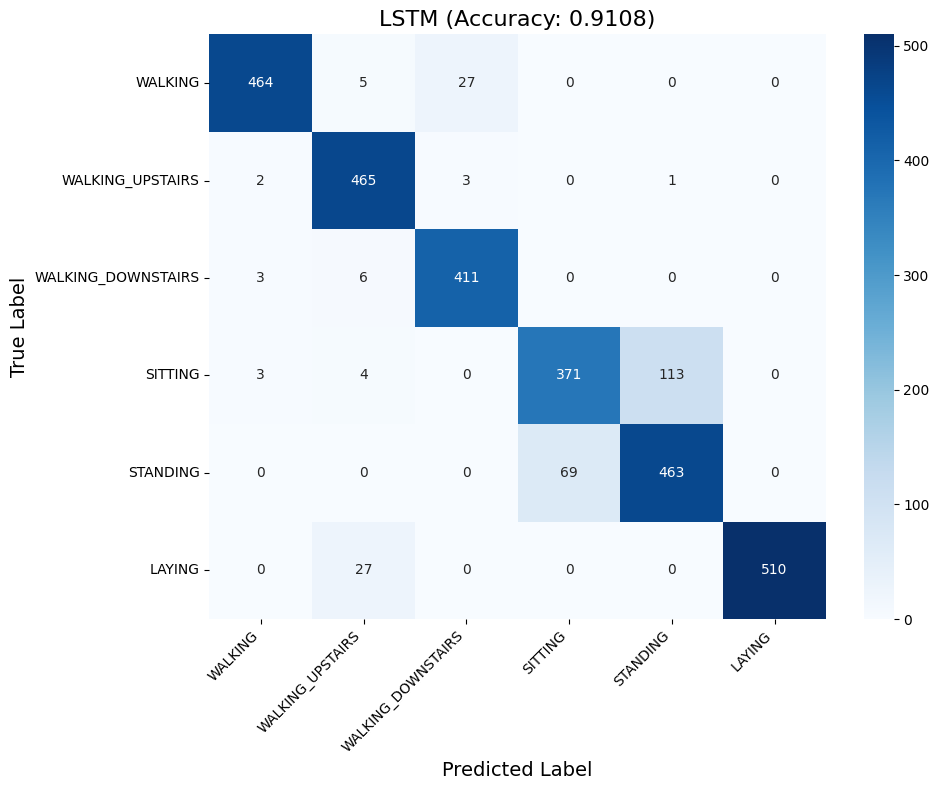

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# --- 1. y_test 원-핫 → 정답 레이블 복원 ---
y_true_labels = np.argmax(y_test_onehot, axis=1)

# --- 2. LSTM 모델 예측 ---
y_pred_lstm_probs = model_lstm.predict(X_test_rnn)
y_pred_lstm_labels = np.argmax(y_pred_lstm_probs, axis=1)

# --- 3. 라벨 이름 ---
activity_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
                  'SITTING', 'STANDING', 'LAYING']

# --- 4. 혼동 행렬 계산 ---
cm_lstm = confusion_matrix(y_true_labels, y_pred_lstm_labels)

# --- 5. 혼동 행렬 그래프 1개만 그리기 ---
plt.figure(figsize=(10, 8))
plt.title(f'LSTM (Accuracy: {acc_lstm:.4f})', fontsize=16)

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names, yticklabels=activity_names)

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
